In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import MNIST
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# (1) Generating five images passing five noise vectors/matrices drawn from a normal distribution with mean 5 and variance through the Decoder of your normal  Autoencoder.

In [2]:
# transform to data to tensor
transform = transforms.Compose([transforms.ToTensor()])

In [3]:
train_dataset_full = MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset_full = MNIST(root='./data', train=False, download=True, transform=transform)

In [4]:
# Data loader
BATCH_SIZE_P1 = 256
train_loader_p1 = DataLoader(train_dataset_full, batch_size=BATCH_SIZE_P1, shuffle=True)
test_loader_p1 = DataLoader(test_dataset_full, batch_size=BATCH_SIZE_P1, shuffle=False)

# simple autoencoder model 

In [5]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim=784, latent_dim=32):
        super(AutoEncoder, self).__init__()
        
        # Encoder: Keras's Functional API is combined into a single nn.Module
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
            nn.ReLU()
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid() # Use Sigmoid for output in range [0, 1]
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [6]:
LATENT_DIM_P1 = 32
INPUT_DIM_P1 = 784
model_p1 = AutoEncoder(input_dim=INPUT_DIM_P1, latent_dim=LATENT_DIM_P1).to(device)
criterion_p1 = nn.MSELoss() # mean_squared_error
optimizer_p1 = optim.Adam(model_p1.parameters(), lr=1e-3)
NUM_EPOCHS_P1 = 50

# Training the autoEncoder

In [7]:
for epoch in range(NUM_EPOCHS_P1):
    model_p1.train()
    running_loss = 0.0
    for data, _ in train_loader_p1:
        # Flatten the images and move to device
        inputs = data.view(data.size(0), -1).to(device)
        
        # Zero the gradients
        optimizer_p1.zero_grad()
        
        # Forward pass
        outputs = model_p1(inputs)
        loss = criterion_p1(outputs, inputs)
        
        # Backward pass and optimize
        loss.backward()
        optimizer_p1.step()
        
        running_loss += loss.item() * inputs.size(0)
    
    epoch_loss = running_loss / len(train_loader_p1.dataset)
    
    # Validation
    model_p1.eval()
    val_loss = 0.0
    with torch.no_grad():
        for data, _ in test_loader_p1:
            inputs = data.view(data.size(0), -1).to(device)
            outputs = model_p1(inputs)
            loss = criterion_p1(outputs, inputs)
            val_loss += loss.item() * inputs.size(0)
    
    val_loss /= len(test_loader_p1.dataset)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS_P1}], Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch [1/50], Train Loss: 0.0693, Val Loss: 0.0407
Epoch [2/50], Train Loss: 0.0330, Val Loss: 0.0271
Epoch [3/50], Train Loss: 0.0246, Val Loss: 0.0216
Epoch [4/50], Train Loss: 0.0202, Val Loss: 0.0185
Epoch [5/50], Train Loss: 0.0181, Val Loss: 0.0171
Epoch [6/50], Train Loss: 0.0167, Val Loss: 0.0159
Epoch [7/50], Train Loss: 0.0159, Val Loss: 0.0152
Epoch [8/50], Train Loss: 0.0152, Val Loss: 0.0145
Epoch [9/50], Train Loss: 0.0146, Val Loss: 0.0139
Epoch [10/50], Train Loss: 0.0142, Val Loss: 0.0136
Epoch [11/50], Train Loss: 0.0138, Val Loss: 0.0133
Epoch [12/50], Train Loss: 0.0136, Val Loss: 0.0130
Epoch [13/50], Train Loss: 0.0132, Val Loss: 0.0127
Epoch [14/50], Train Loss: 0.0129, Val Loss: 0.0125
Epoch [15/50], Train Loss: 0.0127, Val Loss: 0.0122
Epoch [16/50], Train Loss: 0.0124, Val Loss: 0.0120
Epoch [17/50], Train Loss: 0.0122, Val Loss: 0.0118
Epoch [18/50], Train Loss: 0.0120, Val Loss: 0.0117
Epoch [19/50], Train Loss: 0.0119, Val Loss: 0.0115
Epoch [20/50], Train 

Shape of generated noise vectors: torch.Size([5, 32])


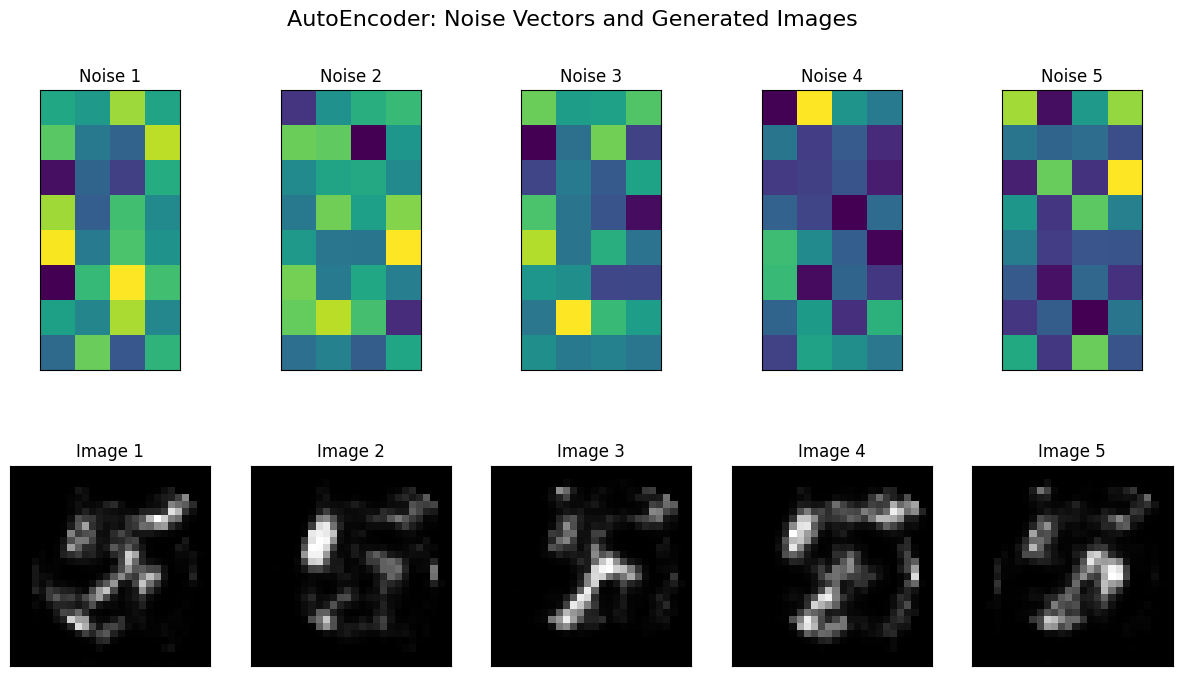

In [19]:
n = 5
noise_mean = 5.0
noise_variance = 1.0
noise_stddev = np.sqrt(noise_variance)

# Generate noise and convert to PyTorch tensor
noise_vectors = np.random.normal(loc=noise_mean, scale=noise_stddev, size=(n, LATENT_DIM_P1))
noise_tensors = torch.from_numpy(noise_vectors).float().to(device)

print(f"Shape of generated noise vectors: {noise_tensors.shape}")

# Generate images using the decoder
model_p1.eval()
with torch.no_grad():
    # Use the decoder part of the model
    generated_images_flat = model_p1.decoder(noise_tensors)
    # Move to CPU and convert to numpy for plotting
    generated_images = generated_images_flat.cpu().numpy().reshape(n, 28, 28)

plt.figure(figsize=(15, 8))
plt.suptitle("AutoEncoder: Noise Vectors and Generated Images", fontsize=16)

for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(noise_vectors[i].reshape(8, 4), cmap='viridis')
    plt.title(f"Noise {i+1}")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(generated_images[i], cmap='gray')
    plt.title(f"Image {i+1}")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

# (2) Generating five images passing five noise vectors/matrices drawn from a normal distribution with mean 5 and variance through the Decoder of your Denoising  Autoencoder.


In [9]:
x_train_tensor = train_dataset_full.data.float() / 255.0
x_test_tensor = test_dataset_full.data.float() / 255.0
x_train_tensor = x_train_tensor.unsqueeze(1) # Add channel dimension -> (N, 1, 28, 28)
x_test_tensor = x_test_tensor.unsqueeze(1)

noise_factor = 0.4
x_train_noisy = x_train_tensor + noise_factor * torch.randn_like(x_train_tensor)
x_test_noisy = x_test_tensor + noise_factor * torch.randn_like(x_test_tensor)

# Clip the values to be between 0 and 1
x_train_noisy = torch.clip(x_train_noisy, 0., 1.)
x_test_noisy = torch.clip(x_test_noisy, 0., 1.)

# Create TensorDatasets and DataLoaders. The input is noisy, the target is clean.
train_dataset_p2 = TensorDataset(x_train_noisy, x_train_tensor)
test_dataset_p2 = TensorDataset(x_test_noisy, x_test_tensor)

BATCH_SIZE_P2 = 128
train_loader_p2 = DataLoader(train_dataset_p2, batch_size=BATCH_SIZE_P2, shuffle=True)
test_loader_p2 = DataLoader(test_dataset_p2, batch_size=BATCH_SIZE_P2, shuffle=False)

In [10]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super(DenoisingAutoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # -> 14x14
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # -> 7x7
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, latent_dim),
            nn.ReLU()
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32 * 7 * 7),
            nn.ReLU(),
            nn.Unflatten(1, (32, 7, 7)), # Reshape to (C, H, W)
            nn.ConvTranspose2d(32, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 28x28
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, padding='same'),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Train the Denoising Autoencoder

In [11]:
LATENT_DIM_P2 = 32
model_p2 = DenoisingAutoencoder(latent_dim=LATENT_DIM_P2).to(device)
criterion_p2 = nn.BCELoss() # binary_crossentropy
optimizer_p2 = optim.Adam(model_p2.parameters(), lr=1e-3)
NUM_EPOCHS_P2 = 50

for epoch in range(NUM_EPOCHS_P2):
    model_p2.train()
    running_loss = 0.0
    for noisy_data, clean_data in train_loader_p2:
        noisy_data, clean_data = noisy_data.to(device), clean_data.to(device)
        
        optimizer_p2.zero_grad()
        outputs = model_p2(noisy_data)
        loss = criterion_p2(outputs, clean_data)
        loss.backward()
        optimizer_p2.step()
        
        running_loss += loss.item() * noisy_data.size(0)
    
    epoch_loss = running_loss / len(train_loader_p2.dataset)
    
    model_p2.eval()
    val_loss = 0.0
    with torch.no_grad():
        for noisy_data, clean_data in test_loader_p2:
            noisy_data, clean_data = noisy_data.to(device), clean_data.to(device)
            outputs = model_p2(noisy_data)
            loss = criterion_p2(outputs, clean_data)
            val_loss += loss.item() * noisy_data.size(0)
            
    val_loss /= len(test_loader_p2.dataset)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS_P2}], Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch [1/50], Train Loss: 0.2635, Val Loss: 0.1603
Epoch [2/50], Train Loss: 0.1407, Val Loss: 0.1292
Epoch [3/50], Train Loss: 0.1264, Val Loss: 0.1218
Epoch [4/50], Train Loss: 0.1204, Val Loss: 0.1160
Epoch [5/50], Train Loss: 0.1157, Val Loss: 0.1130
Epoch [6/50], Train Loss: 0.1130, Val Loss: 0.1108
Epoch [7/50], Train Loss: 0.1113, Val Loss: 0.1103
Epoch [8/50], Train Loss: 0.1099, Val Loss: 0.1090
Epoch [9/50], Train Loss: 0.1089, Val Loss: 0.1082
Epoch [10/50], Train Loss: 0.1079, Val Loss: 0.1069
Epoch [11/50], Train Loss: 0.1071, Val Loss: 0.1065
Epoch [12/50], Train Loss: 0.1064, Val Loss: 0.1056
Epoch [13/50], Train Loss: 0.1058, Val Loss: 0.1050
Epoch [14/50], Train Loss: 0.1054, Val Loss: 0.1049
Epoch [15/50], Train Loss: 0.1049, Val Loss: 0.1041
Epoch [16/50], Train Loss: 0.1044, Val Loss: 0.1038
Epoch [17/50], Train Loss: 0.1040, Val Loss: 0.1034
Epoch [18/50], Train Loss: 0.1037, Val Loss: 0.1033
Epoch [19/50], Train Loss: 0.1034, Val Loss: 0.1032
Epoch [20/50], Train 

# Generating Images from Noise

Shape of generated noise vectors: torch.Size([5, 32])


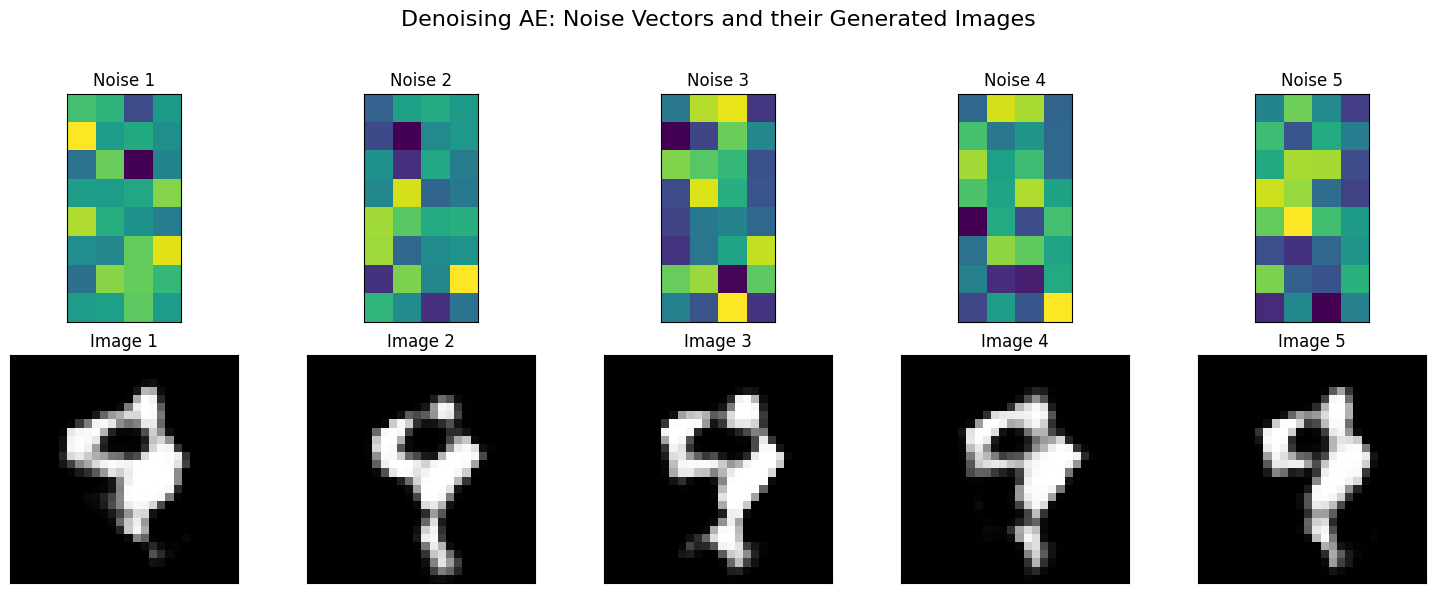

In [20]:
n = 5
# Same noise parameters as before
noise_vectors_p2 = np.random.normal(loc=noise_mean, scale=noise_stddev, size=(n, LATENT_DIM_P2))
noise_tensors_p2 = torch.from_numpy(noise_vectors_p2).float().to(device)

print(f"Shape of generated noise vectors: {noise_tensors_p2.shape}")

model_p2.eval()
with torch.no_grad():
    generated_images_p2 = model_p2.decoder(noise_tensors_p2)
    generated_images_p2 = generated_images_p2.cpu().numpy()

plt.figure(figsize=(15, 6))
plt.suptitle("Denoising AE: Noise Vectors and their Generated Images", fontsize=16)

for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(noise_vectors_p2[i].reshape(8, 4), cmap='viridis')
    plt.title(f"Noise {i+1}")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(generated_images_p2[i].reshape(28, 28), cmap='gray')
    plt.title(f"Image {i+1}")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# (3) Training and evaluating a Variational Autoencoder Generating five images passing five noise vectors/matrices drawn from a normal distribution with mean 5 and variance through the Decoder of your Variational  Autoencoder.


In [13]:
train_dataset_p3 = TensorDataset(x_train_tensor, train_dataset_full.targets)
test_dataset_p3 = TensorDataset(x_test_tensor, test_dataset_full.targets)

BATCH_SIZE_P3 = 128
train_loader_p3 = DataLoader(train_dataset_p3, batch_size=BATCH_SIZE_P3, shuffle=True)
test_loader_p3 = DataLoader(test_dataset_p3, batch_size=BATCH_SIZE_P3, shuffle=False)

LATENT_DIM_P3 = 2

In [14]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        # Encoder Part
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 16)
        
        # Latent space layers
        self.fc_mean = nn.Linear(16, LATENT_DIM_P3)
        self.fc_log_var = nn.Linear(16, LATENT_DIM_P3)

        # Decoder Part
        self.fc_decode = nn.Linear(LATENT_DIM_P3, 7 * 7 * 64)
        self.deconv1 = nn.ConvTranspose2d(64, 64, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.deconv2 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.deconv3 = nn.ConvTranspose2d(32, 1, kernel_size=3, padding=1)

    def encode(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1) # Flatten
        x = F.relu(self.fc1(x))
        return self.fc_mean(x), self.fc_log_var(x)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        epsilon = torch.randn_like(std)
        return mu + epsilon * std

    def decode(self, z):
        x = F.relu(self.fc_decode(z))
        x = x.view(-1, 64, 7, 7) # Unflatten
        x = F.relu(self.deconv1(x))
        x = F.relu(self.deconv2(x))
        return torch.sigmoid(self.deconv3(x)) # Use sigmoid for output

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        reconstruction = self.decode(z)
        return reconstruction, mu, log_var

def vae_loss_function(recon_x, x, mu, log_var):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    
    # KL Divergence loss
    # 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    
    return BCE + KLD

# Train the VAE

In [15]:
model_p3 = VAE().to(device)
optimizer_p3 = optim.Adam(model_p3.parameters(), lr=1e-3)
NUM_EPOCHS_P3 = 100

for epoch in range(NUM_EPOCHS_P3):
    model_p3.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader_p3):
        data = data.to(device)
        optimizer_p3.zero_grad()
        
        recon_batch, mu, log_var = model_p3(data)
        loss = vae_loss_function(recon_batch, data, mu, log_var)
        
        loss.backward()
        train_loss += loss.item()
        optimizer_p3.step()
        
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS_P3}], Average Loss: {train_loss / len(train_loader_p3.dataset):.4f}")

Epoch [1/100], Average Loss: 212.8810
Epoch [2/100], Average Loss: 190.0308
Epoch [3/100], Average Loss: 187.0234
Epoch [4/100], Average Loss: 185.2777
Epoch [5/100], Average Loss: 183.9654
Epoch [6/100], Average Loss: 182.7352
Epoch [7/100], Average Loss: 181.8868
Epoch [8/100], Average Loss: 181.0539
Epoch [9/100], Average Loss: 180.1219
Epoch [10/100], Average Loss: 179.4525
Epoch [11/100], Average Loss: 178.7540
Epoch [12/100], Average Loss: 178.1934
Epoch [13/100], Average Loss: 177.5975
Epoch [14/100], Average Loss: 177.1567
Epoch [15/100], Average Loss: 176.7576
Epoch [16/100], Average Loss: 176.3544
Epoch [17/100], Average Loss: 176.0888
Epoch [18/100], Average Loss: 175.7699
Epoch [19/100], Average Loss: 175.3933
Epoch [20/100], Average Loss: 175.1302
Epoch [21/100], Average Loss: 174.9400
Epoch [22/100], Average Loss: 174.7774
Epoch [23/100], Average Loss: 174.4910
Epoch [24/100], Average Loss: 174.3207
Epoch [25/100], Average Loss: 174.2433
Epoch [26/100], Average Loss: 173.

# Evaluate the VAE

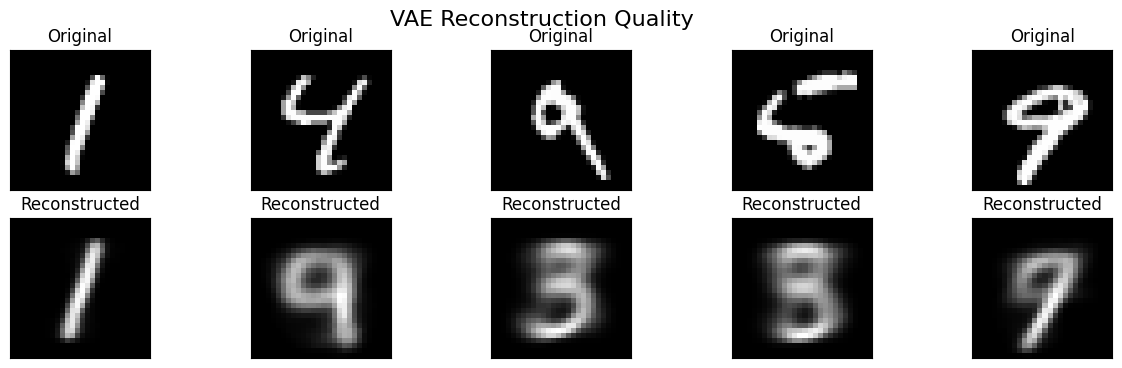

In [18]:

n = 5
sample_images = x_test_tensor[n:n+5].to(device)
model_p3.eval()
with torch.no_grad():
    reconstructed_images, _, _ = model_p3(sample_images)
    reconstructed_images = reconstructed_images.cpu()

plt.figure(figsize=(15, 4))
plt.suptitle("VAE Reconstruction Quality", fontsize=16)
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(sample_images[i].cpu().reshape(28, 28), cmap='gray')
    ax.set_title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_images[i].reshape(28, 28), cmap='gray')
    ax.set_title("Reconstructed")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

# Plotting the latent space

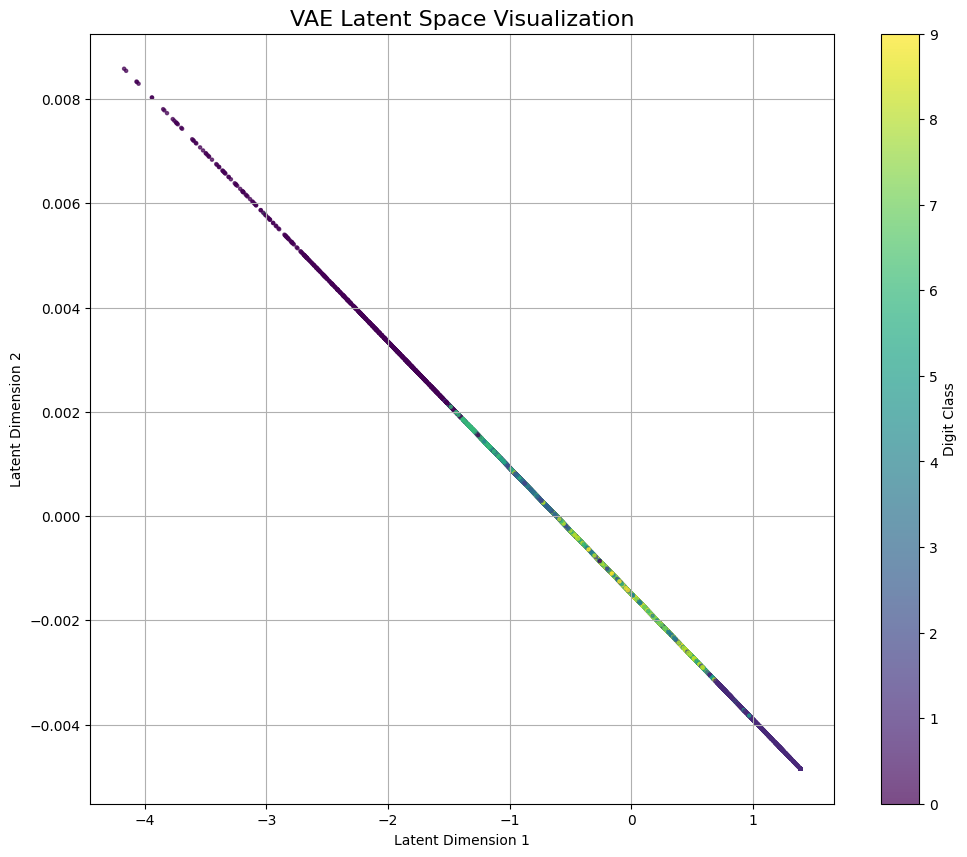

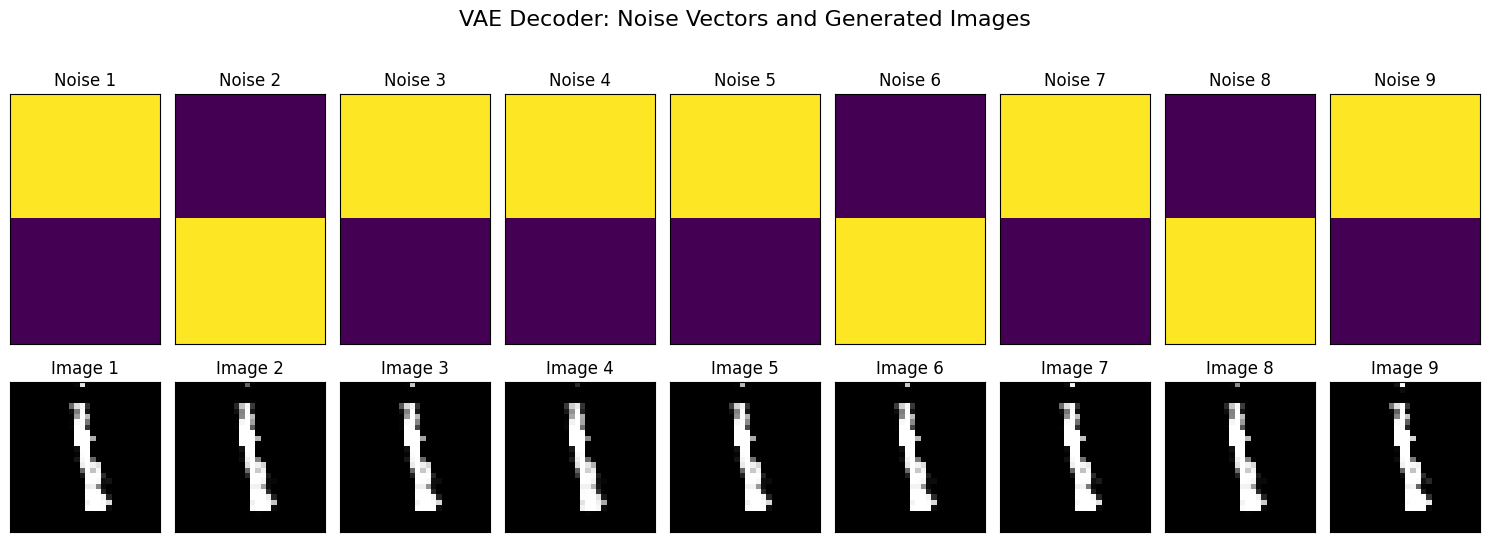

In [17]:

z_means = []
true_labels = []
model_p3.eval()
with torch.no_grad():
    for data, labels in test_loader_p3:
        data = data.to(device)
        mu, _ = model_p3.encode(data)
        z_means.append(mu.cpu())
        true_labels.append(labels)

z_means = torch.cat(z_means, dim=0).numpy()
true_labels = torch.cat(true_labels, dim=0).numpy()

plt.figure(figsize=(12, 10))
plt.scatter(z_means[:, 0], z_means[:, 1], c=true_labels, cmap='viridis', s=5, alpha=0.7)
plt.colorbar(label='Digit Class')
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("VAE Latent Space Visualization", fontsize=16)
plt.grid(True)
plt.show()

n = 9
noise_vectors_p3 = np.random.normal(loc=noise_mean, scale=noise_stddev, size=(n, LATENT_DIM_P3))
noise_tensors_p3 = torch.from_numpy(noise_vectors_p3).float().to(device)

model_p3.eval()
with torch.no_grad():
    generated_images_p3 = model_p3.decode(noise_tensors_p3).cpu().numpy()

plt.figure(figsize=(15, 6))
plt.suptitle("VAE Decoder: Noise Vectors and Generated Images", fontsize=16)
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(noise_vectors_p3[i].reshape(2, 1), cmap='viridis', aspect='auto')
    plt.title(f"Noise {i+1}")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(generated_images_p3[i].reshape(28, 28), cmap='gray')
    plt.title(f"Image {i+1}")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()